In [1]:
import sys; sys.path.append("..")
import json, os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

from src.data import load_adult
from src.models import build_models
from src.tuning import tune_xgb, XGB_KEY

os.makedirs("../results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
X_train, X_test, y_train, y_test = load_adult()

In [ ]:
# Hyperparameter Tuning for XGBoost
study, default_score = tune_xgb(X_train, y_train, n_trials=40, cv_splits=5)
print(f"default params, tuning folds:   {default_score:.4f}")
print(f"best trial, tuning folds:       {study.best_value:.4f}  (optimistic, see cell 4)")
print(study.best_params)

study.trials_dataframe().to_csv("../results/optuna_trials.csv", index=False)
with open("../results/best_xgb_params.json", "w") as f:
    json.dump(study.best_params, f, indent=2)

default params, tuning folds:   0.9232
best trial, tuning folds:       0.9293  (optimistic, see cell 4)
{'n_estimators': 450, 'learning_rate': 0.06350483853983785, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.841809730765818, 'colsample_bytree': 0.51525616049528, 'reg_lambda': 1.1168923128987642, 'reg_alpha': 0.2617850559943537}


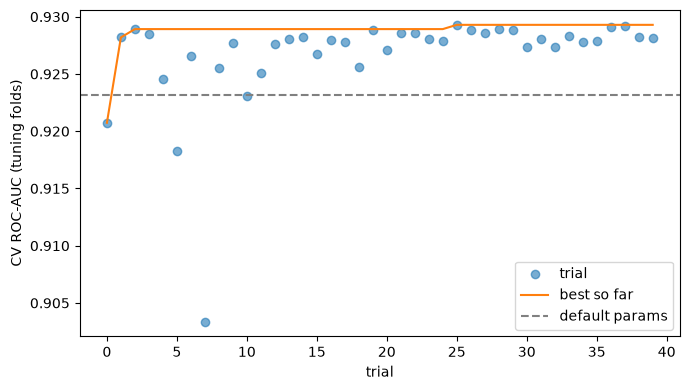

In [ ]:
# Visualize the optimization history
vals = pd.Series([t.value for t in study.trials])
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(vals.index, vals, alpha=0.6, label="trial")
ax.plot(vals.cummax(), color="C1", label="best so far")
ax.axhline(default_score, color="gray", ls="--", label="default params")
ax.set_xlabel("trial")
ax.set_ylabel("CV ROC-AUC (tuning folds)")
ax.legend()
fig.tight_layout()
fig.savefig("../figures/optuna_history.png", dpi=150)
plt.show()

In [ ]:
# Fresh Fold Evaluation
cv_fresh = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=123)

def fresh_scores(params):
    m = build_models(X_train, xgb_params=params)[XGB_KEY]
    return cross_val_score(m, X_train, y_train, cv=cv_fresh, scoring="roc_auc", n_jobs=1)

default_s = fresh_scores({})
tuned_s = fresh_scores(study.best_params)
diff = tuned_s - default_s

pd.DataFrame({"default": default_s, "tuned": tuned_s, "diff": diff}).to_csv(
    "../results/fresh_fold_default_vs_tuned.csv", index=False)

print(f"default: {default_s.mean():.4f} ± {default_s.std():.4f}")
print(f"tuned:   {tuned_s.mean():.4f} ± {tuned_s.std():.4f}")
print(f"paired gain: {diff.mean():+.4f} ± {diff.std():.4f}  "
      f"(tuned wins {(diff > 0).sum()}/{len(diff)} folds)")

default: 0.9240 ± 0.0034
tuned:   0.9293 ± 0.0035
paired gain: +0.0053 ± 0.0007  (tuned wins 15/15 folds)
